# Ad Click-Through Rate (CTR) Prediction

Predicts probability of a user clicking an ad, using the Avazu CTR dataset
schema (mobile ad impressions: site/app/device features + a binary click label).

Pipeline: EDA -> feature engineering -> Logistic Regression baseline ->
XGBoost -> evaluation (AUC-ROC, Log Loss) -> class imbalance handling.

**Dataset**: place the real Avazu (or Criteo) `train.csv` from Kaggle at
`data/train.csv` before running — see README for download + sampling steps.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss, roc_curve, classification_report
import xgboost as xgb

sns.set_style("whitegrid")
RANDOM_STATE = 42

## 1. Load data

In [2]:
df = pd.read_csv("data/train.csv")
print(df.shape)
df.head()

(2000000, 24)


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
3,1.000064e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15706,320,50,1722,0,35,100084,79
4,1.000068e+19,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,...,1,0,18993,320,50,2161,0,35,-1,157


## 2. EDA

Check class balance first — CTR datasets are heavily imbalanced (typically
5-20% positive), which drives every modeling decision downstream.

Overall CTR: 0.1616


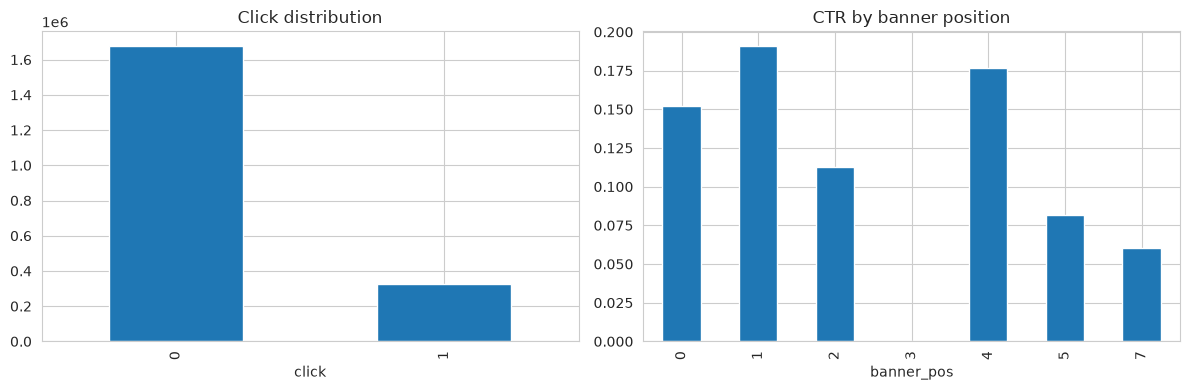

In [3]:
click_rate = df["click"].mean()
print(f"Overall CTR: {click_rate:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["click"].value_counts().plot(kind="bar", ax=axes[0], title="Click distribution")

df.groupby("banner_pos")["click"].mean().plot(kind="bar", ax=axes[1], title="CTR by banner position")
plt.tight_layout()
plt.savefig("outputs/eda_overview.png", dpi=120)
plt.show()

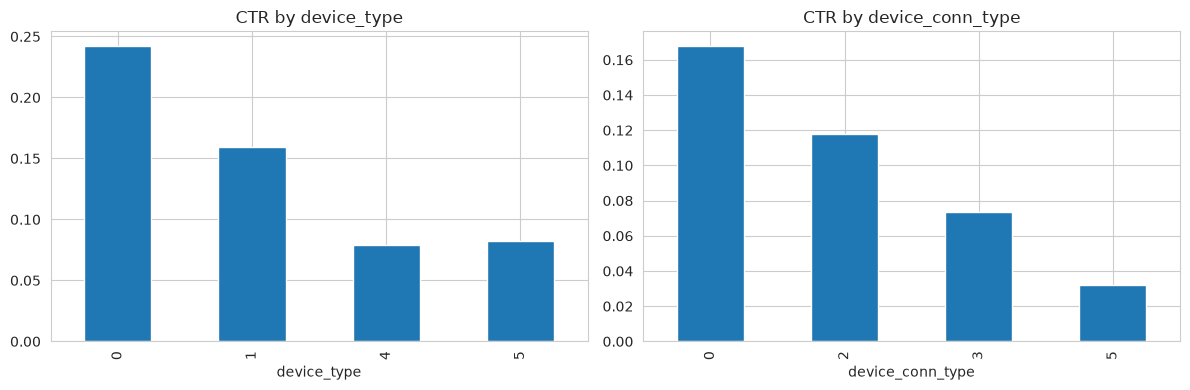

In [4]:
# CTR by device type and connection type — sanity check for signal before modeling
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df.groupby("device_type")["click"].mean().plot(kind="bar", ax=axes[0], title="CTR by device_type")
df.groupby("device_conn_type")["click"].mean().plot(kind="bar", ax=axes[1], title="CTR by device_conn_type")
plt.tight_layout()
plt.savefig("outputs/eda_device.png", dpi=120)
plt.show()

## 3. Feature engineering

- Parse `hour` (format `YYMMDDHH`) into actual time-based features — hour of
  day and day of week matter a lot for ad engagement.
- Label-encode high-cardinality categoricals (site_id, app_id, etc.). For the
  full 40M-row Avazu set, prefer hashing (`FeatureHasher`) over one-hot to
  avoid blowing up memory — noted here, not needed at this sample size.

In [5]:
df["hour_dt"] = pd.to_datetime(df["hour"], format="%y%m%d%H")
df["hour_of_day"] = df["hour_dt"].dt.hour
df["day_of_week"] = df["hour_dt"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

categorical_cols = [
    "C1", "banner_pos", "site_id", "site_category", "app_id", "app_category",
    "device_type", "device_conn_type", "C19", "C20",
]
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

feature_cols = categorical_cols + ["C14", "C17", "C21", "hour_of_day", "day_of_week", "is_weekend"]
X = df[feature_cols]
y = df["click"]

## 4. Train / test split

Time-based split is more realistic for CTR (train on earlier hours, test on
later ones — avoids leaking future patterns backward). Using a random
stratified split here since the synthetic data has no real temporal signal;
**switch to a time-based split on the real dataset.**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train CTR: {y_train.mean():.4f}, Test CTR: {y_test.mean():.4f}")

Train: (1600000, 16), Test: (400000, 16)
Train CTR: 0.1616, Test CTR: 0.1616


## 5. Baseline — Logistic Regression

`class_weight="balanced"` handles the imbalance by reweighting the loss
instead of resampling — keeps all the data, cheap, and a defensible default
to justify in an interview.

In [7]:
lr = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
lr.fit(X_train, y_train)

lr_probs = lr.predict_proba(X_test)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)
lr_logloss = log_loss(y_test, lr_probs)
print(f"Logistic Regression -> AUC: {lr_auc:.4f}, Log Loss: {lr_logloss:.4f}")

/home/abstract/ctr-venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression -> AUC: 0.6121, Log Loss: 0.6693


## 6. XGBoost

Gradient-boosted trees capture non-linear feature interactions (e.g.
banner_pos x device_type) that logistic regression misses. `scale_pos_weight`
is XGBoost's equivalent imbalance handling — ratio of negative to positive
class counts.

In [8]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_probs)
xgb_logloss = log_loss(y_test, xgb_probs)
print(f"XGBoost -> AUC: {xgb_auc:.4f}, Log Loss: {xgb_logloss:.4f}")

scale_pos_weight: 5.19


XGBoost -> AUC: 0.7500, Log Loss: 0.5899


## 7. Model comparison

              Model  AUC-ROC  Log Loss
Logistic Regression 0.612143  0.669304
            XGBoost 0.749954  0.589883


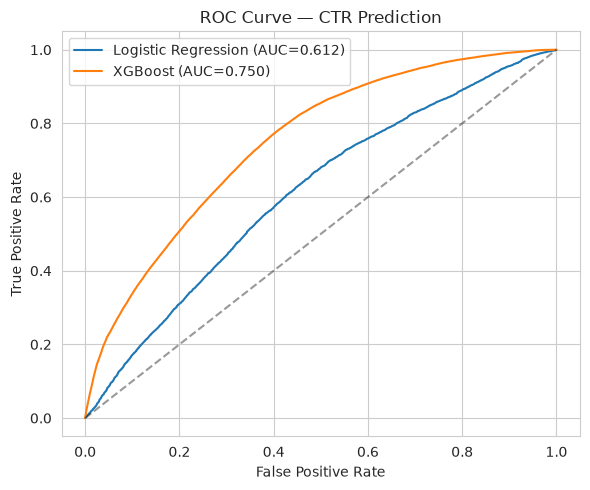

In [9]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "XGBoost"],
    "AUC-ROC": [lr_auc, xgb_auc],
    "Log Loss": [lr_logloss, xgb_logloss],
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 5))
for name, probs in [("Logistic Regression", lr_probs), ("XGBoost", xgb_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — CTR Prediction")
ax.legend()
plt.tight_layout()
plt.savefig("outputs/roc_curve.png", dpi=120)
plt.show()

## 8. Feature importance (XGBoost)

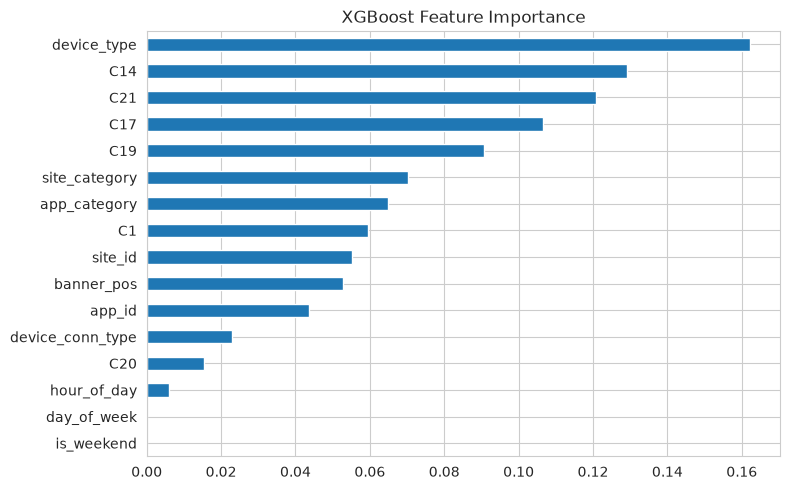

device_type         0.162165
C14                 0.129007
C21                 0.120774
C17                 0.106553
C19                 0.090711
site_category       0.070346
app_category        0.064817
C1                  0.059461
site_id             0.055272
banner_pos          0.052895
app_id              0.043742
device_conn_type    0.022849
C20                 0.015343
hour_of_day         0.006065
day_of_week         0.000000
is_weekend          0.000000
dtype: float32


In [10]:
importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 5))
importance.plot(kind="barh", ax=ax)
ax.set_title("XGBoost Feature Importance")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=120)
plt.show()

print(importance)

## 9. Notes on class imbalance handling

Three approaches, in the order I'd reach for them:
1. **Class weighting** (`class_weight`/`scale_pos_weight`) — used above, no
   data loss, cheapest to justify.
2. **Threshold tuning** — CTR models are usually consumed as ranked
   probabilities (for ad auction bidding), not hard 0/1 labels, so accuracy
   at a 0.5 threshold is close to meaningless here. AUC and Log Loss matter
   more than precision/recall at a fixed cutoff.
3. **Resampling** (SMOTE/undersampling) — last resort; riskier with
   high-cardinality categorical features since synthetic minority samples
   can produce nonsensical category combinations.

## 10. Next steps (not implemented — scope notes for interview discussion)
- Target/frequency encoding for high-cardinality IDs (site_id, app_id)
  instead of label encoding, with out-of-fold computation to avoid leakage.
- Feature hashing for the full 40M-row dataset to control memory.
- Time-based (not random) train/test split on real data.
- Calibration check (predicted probability vs actual CTR) since this feeds
  an ad auction, not just a classifier.